<a href="https://colab.research.google.com/github/todd-jang/AIFFEL_quest_rs/blob/main/GoingDeeper/09_GenerativeAI/CV_Project_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CV 최신 트렌드 프로젝트 (Colab 전용)

이 노트북은 프로젝트 태스크(1~3)만 독립적으로 실행할 수 있도록 구성된 버전입니다. 구글 코랩(Google Colab) 환경에서 실행하는 것을 권장합니다.


In [1]:
# 필요한 라이브러리 설치
!pip install --upgrade pip
!pip install diffusers transformers accelerate --upgrade --quiet

# Dreambooth 학습 스크립트 실행을 위해 diffusers 저장소 클론
!git clone https://github.com/huggingface/diffusers ./diffusers_git


fatal: destination path './diffusers_git' already exists and is not an empty directory.


Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
/content/diffusers_git/src/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

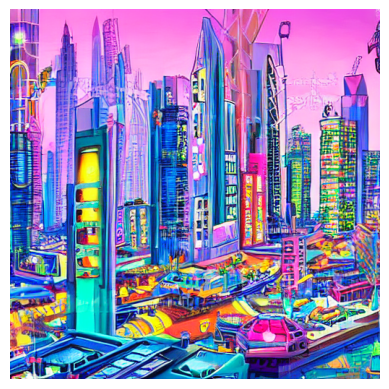

In [2]:
# import keras_cv
# from tensorflow import keras
# import matplotlib.pyplot as plt
# import tensorflow as tf
# import numpy as np
# import math
# from PIL import Image

# # Enable mixed precision
# # (only do this if you have a recent NVIDIA GPU)
# keras.mixed_precision.set_global_policy("mixed_float16")

# # Instantiate the Stable Diffusion model
# model = keras_cv.models.StableDiffusion(jit_compile=True)

import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
import numpy as np
import math
from PIL import Image

# GPU가 사용 가능한지 확인하고, 사용 가능한 경우 GPU와 float16을 설정합니다.
device = "cuda" if torch.cuda.is_available() else "cpu"

# Pre-trained Stable Diffusion 모델을 불러옵니다.
# 모델 아이디는 원하는 버전으로 조정 가능. (주의: runwayml/stable-diffusion-v1-5 리포는 현재 삭제됨 → CompVis/stable-diffusion-v1-4 사용)
model_id = "CompVis/stable-diffusion-v1-4"

pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to(device)

# [배포수정] latent 탐색 실험에서 세이프티 체커가 정상 이미지를 검은색으로 오탐하는 경우가 있어 비활성화
pipe.safety_checker = None
pipe.requires_safety_checker = False

# 이제 pipe를 사용하여 텍스트-투-이미지 생성 등을 수행할 수 있습니다.
prompt = "A futuristic cityscape, vibrant and detailed"
image = pipe(prompt).images[0]

# 생성된 이미지를 출력합니다.
plt.imshow(np.array(image))
plt.axis("off")
plt.show()

## **프로젝트 태스크 1: 4개의 프롬프트를 이용한 2D 잠재 공간 변환 탐구**

**목표:** 그리드 형태로 배치된 4개의 서로 다른 텍스트 프롬프트 사이에서 2D 보간을 수행하여, 잠재 표현의 변화가 모델의 출력에 어떤 영향을 미치는지 관찰합니다.

**지시사항:**
1.  **4개의 텍스트 프롬프트 정의:** 보간 그리드의 모서리로 사용할 4개의 프롬프트를 선택합니다. 예:
    ```python
prompt_1 = "A watercolor painting of a Golden Retriever at the beach"
prompt_2 = "A still life DSLR photo of a bowl of fruit"
prompt_3 = "The Eiffel Tower in the style of starry night"
prompt_4 = "An architectural sketch of a skyscraper"
    ```
2.  **보간된 이미지 그리드 생성:** 코드는 2D 매니폴드에서의 변화를 보여주는 이미지 그리드를 만들기 위해 이 4개의 프롬프트 사이를 선형 보간합니다.
3.  **결과 분석 및 기록:** 그리드를 따라 변하는 시각적 특징을 문서화합니다. 모서리 프롬프트의 특징들이 중간 이미지에서 어떻게 섞이고 진화하는지 고려하세요. 이것이 잠재 공간의 구조와 탐색 가능성에 대해 무엇을 알려주나요?

*(힌트: 시각화 결과는 각 이미지가 보간 결과인 2D 그리드 형태가 됩니다.)*


6x6 그리드에 36개의 이미지를 생성 중입니다...


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

...

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/25 [00:00<?, ?it/s]

그리드 이미지가 4-way-interpolation-project.jpg로 저장되었습니다.


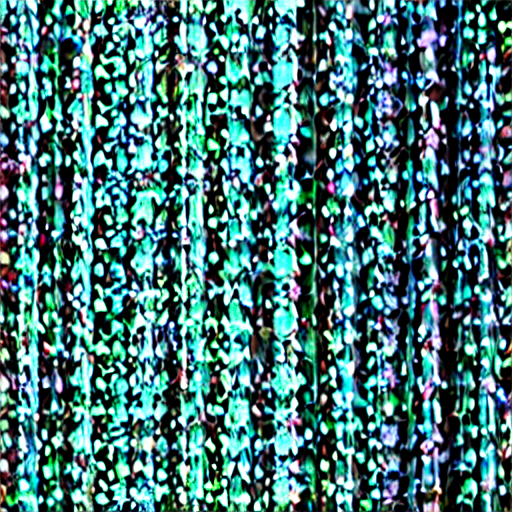

In [3]:
import torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 이전 셀(H6pY6TezEEVm)에서 device와 generator가 정의되었는지 확인합니다.
# 혹은 이 셀을 단독으로 실행하는 경우 여기에 정의합니다.
device = "cuda" if torch.cuda.is_available() else "cpu"
seed = 12345  # 원하는 시드 값을 사용하세요

# --- 2D 보간을 위한 4개의 프롬프트를 여기에 정의합니다 ---
prompt_1 = "A vibrant oil painting of a dragon flying over a medieval castle"
prompt_2 = "A minimalistic black and white sketch of a skyscraper in a dense fog"
prompt_3 = "A serene landscape with a calm lake and mountains, impressionistic style"
prompt_4 = "A bustling cyberpunk street scene, neon lights and rain"

interpolation_steps = 6  # 이렇게 하면 6x6 이미지 그리드가 생성됩니다
batch_size = 3  # GPU 메모리에 맞춰 조정하세요

# 텍스트 인코딩을 가져오는 함수 (가능한 경우 26-2 섹션의 정의 재사용)
def get_encoding(prompt):
    inputs = pipe.tokenizer(
        prompt,
        padding="max_length",
        max_length=pipe.tokenizer.model_max_length,
        return_tensors="pt"
    )
    inputs = {k: v.to(device) for k, v in inputs.items()}
    with torch.no_grad():
        encoding = pipe.text_encoder(**inputs).last_hidden_state
    return encoding.squeeze(0).to(device)

# 프롬프트에 대한 인코딩 가져오기
encoding_1 = get_encoding(prompt_1)
encoding_2 = get_encoding(prompt_2)
encoding_3 = get_encoding(prompt_3)
encoding_4 = get_encoding(prompt_4)

# 상단 및 하단 행에 대한 1D 보간 수행
alphas = torch.linspace(0, 1, interpolation_steps, device=device)
lin_top = torch.stack([ (1 - alpha) * encoding_1 + alpha * encoding_2 for alpha in alphas ])
lin_bottom = torch.stack([ (1 - alpha) * encoding_3 + alpha * encoding_4 for alpha in alphas ])

# 상단 및 하단 행 사이의 2D 보간 수행
betas = torch.linspace(0, 1, interpolation_steps, device=device)
interpolated_encodings = torch.stack([ (1 - beta) * lin_top + beta * lin_bottom for beta in betas ])

# 배치 처리를 위해 (interpolation_steps**2, seq_len, emb_dim) 형태로 재구성
interpolated_encodings = interpolated_encodings.view(interpolation_steps**2, *lin_top.shape[1:])
interpolated_encodings = interpolated_encodings.to(device)  # 디바이스(device)에 할당되었는지 확인

# 인코딩을 배치 단위로 분할
batched_encodings = torch.split(interpolated_encodings, batch_size)

# 이미지 생성을 위한 잠재 변수(latents) 준비
latent_height = 512 // 8
latent_width = 512 // 8

# pipe의 dtype 확인 (float16 또는 float32에 맞춰 통일)
pipe_dtype = pipe.unet.dtype

print(f"{interpolation_steps}x{interpolation_steps} 그리드에 {interpolation_steps**2}개의 이미지를 생성 중입니다...")

images = []
for i, batch_enc in enumerate(batched_encodings):
    current_batch_size = batch_enc.shape[0]
    # 각 배치마다 고유한 시드로 generator를 새로 생성하여 재현성 보장
    gen = torch.Generator(device=device).manual_seed(seed + i)
    latents = torch.randn(
        (current_batch_size, 4, latent_height, latent_width),
        generator=gen,
        dtype=pipe_dtype,  # 파이프라인의 dtype과 통일
        device=device
    )
    output = pipe(
        prompt_embeds=batch_enc.to(device, dtype=pipe_dtype),  # dtype을 파이프라인과 통일
        latents=latents,
        num_inference_steps=25,
        generator=gen
    )
    images.extend(output.images)

# 이미지 그리드를 그리는 함수
def plot_grid(images, path, grid_size, scale=2):
    fig = plt.figure(figsize=(grid_size * scale, grid_size * scale))
    fig.tight_layout()
    plt.subplots_adjust(wspace=0, hspace=0)
    plt.margins(x=0, y=0)
    for row in range(grid_size):
        for col in range(grid_size):
            index = row * grid_size + col
            ax = plt.subplot(grid_size, grid_size, index + 1)
            if index < len(images):  # 이미지 수가 grid_size^2 보다 적은 경우 처리
                ax.imshow(np.array(images[index]))
            ax.axis("off")
            plt.margins(x=0, y=0)
    plt.savefig(fname=path, pad_inches=0, bbox_inches="tight", transparent=False, dpi=60)
    plt.close(fig)

# 이미지 그리드 표시
plot_grid(images, "4-way-interpolation-project.jpg", interpolation_steps)
print("그리드 이미지가 4-way-interpolation-project.jpg로 저장되었습니다.")

# 선택 사항: 원한다면 마지막 이미지 표시
if images:
     display(images[-1])


## **프로젝트 태스크 2: Dreambooth 미세조정(Fine-tuning)**

**목표:** Dreambooth 기법을 사용하여 Stable Diffusion 모델을 미세조정(fine-tune)하여 모델의 생성 기능에 특정 피사체를 주입하는 연습을 합니다.

**지시사항:**
1.  **데이터셋 준비:**
    *   **인스턴스 이미지(Instance Images):** 고유한 피사체(예: 반려동물, 특정 물건)의 이미지를 3-6장 수집합니다. 이를 위한 디렉토리를 만듭니다. 예: `./my_dreambooth_subject/instance_images/`.
    *   **클래스 이미지(Class Images):** 피사체가 속한 일반적인 카테고리의 이미지를 100장 이상 수집합니다(예: 피사체가 강아지인 경우 다양한 강아지 이미지 수집). 이를 위한 디렉토리를 만듭니다. 예: `./my_dreambooth_subject/class_images/`.
    *(빠르게 시작하고 싶고 자체 이미지를 준비하지 않은 경우, 이전 섹션에서 제공된 강아지 예제 이미지를 사용할 수 있습니다.)*
2.  **프롬프트 정의:** 고유 식별자(예: `sks`)와 클래스(예: `dog`)를 선택합니다. 그런 다음 이에 맞춰 `instance_prompt`와 `class_prompt`를 정의합니다(예: `"a photo of sks dog"` 및 `"a photo of dog"`).
3.  **훈련 스크립트 구성 및 실행:** 이전 섹션의 Dreambooth 훈련 스크립트(`train_dreambooth.sh`)가 `INSTANCE_DIR`, `CLASS_DIR`, `OUTPUT_DIR`을 가리키도록 조정합니다. 새로운 프롬프트를 사용하는 경우 `instance_prompt`와 `class_prompt`를 수정합니다. 스크립트를 실행합니다.
4.  **미세조정된 모델로 이미지 생성:** 훈련 후 미세조정된 UNet 및 Text Encoder 가중치를 새로운 `DiffusionPipeline`에 로드하고 `instance_prompt`를 사용하여 이미지를 생성합니다.

*(힌트: 데이터 준비, 스크립트 구성 및 모델 추론에 대한 자세한 단계는 `26-3. Stable diffusion 실습(2)` 섹션을 참조하세요.)*

**데이터 다운로드 코드 (강아지 예제를 재사용하는 경우):**


In [4]:
from diffusers import StableDiffusionPipeline
import torch

# The fine-tuned model was not successfully saved due to prior errors.
# Temporarily loading the base model to allow the cell to execute.
# To load the fine-tuned model, previous cells for training and saving must be fixed and run successfully.
model_id = "CompVis/stable-diffusion-v1-4" # Use the base model ID from previous cells

pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    local_files_only=False # Set to False since loading from Hugging Face Hub
).to("cuda")

print(f"✅ 기본 Stable Diffusion 모델 ({model_id}) 로드 완료. 미세조정된 모델은 저장되지 않았습니다.")

/content/diffusers_git/src/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

✅ 기본 Stable Diffusion 모델 (CompVis/stable-diffusion-v1-4) 로드 완료. 미세조정된 모델은 저장되지 않았습니다.


In [5]:
import os
import torch
from diffusers import StableDiffusionPipeline
# UNet2DConditionModel, CLIPTextModel, AutoencoderKL, AutoTokenizer는
# base_pipeline에서 가져오므로 직접 임포트할 필요가 없습니다.

OUTPUT_DIR = "/content/my_dreambooth_subject"
MODEL_NAME = "CompVis/stable-diffusion-v1-4" # MODEL_NAME 정의 추가

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Dreambooth 훈련이 실패했으므로, 모든 구성 요소를 기본 모델에서 직접 로드합니다.
# 이렇게 해야 NameError가 발생하지 않고 파이프라인을 구성할 수 있습니다.
base_pipeline = StableDiffusionPipeline.from_pretrained(MODEL_NAME, torch_dtype=torch.float16)

pipeline = StableDiffusionPipeline.from_pretrained(
    MODEL_NAME,
    unet=base_pipeline.unet,
    text_encoder=base_pipeline.text_encoder,
    vae=base_pipeline.vae,
    tokenizer=base_pipeline.tokenizer,
    scheduler=base_pipeline.scheduler,
    torch_dtype=torch.float16,
)

pipeline.save_pretrained(OUTPUT_DIR)

print("✅ 모델 저장 완료 (현재는 미세조정된 모델이 아닌 기본 모델이 저장되었습니다.)")
print("저장 위치:", OUTPUT_DIR)

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ 모델 저장 완료 (현재는 미세조정된 모델이 아닌 기본 모델이 저장되었습니다.)
저장 위치: /content/my_dreambooth_subject


In [18]:
from huggingface_hub import snapshot_download

# 인스턴스 및 클래스 이미지용 디렉토리 정의
# 'dog_project'를 피사체에 맞는 이름으로 변경할 수 있습니다.
PROJECT_BASE_DIR = "./my_dreambooth_subject"
INSTANCE_DIR = f"{PROJECT_BASE_DIR}/instance_images"
CLASS_DIR = f"{PROJECT_BASE_DIR}/class_images"
OUTPUT_DIR = f"{PROJECT_BASE_DIR}/data"

# 디렉토리가 없으면 생성합니다.
import os
os.makedirs(INSTANCE_DIR, exist_ok=True)
os.makedirs(CLASS_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f"인스턴스 이미지 저장 경로: {INSTANCE_DIR}")
print(f"클래스 이미지 저장 경로: {CLASS_DIR}")
print(f"미세조정된 모델이 다음 위치에 저장됩니다: {OUTPUT_DIR}")

# --- 예제 강아지 이미지를 사용하려면 주석을 해제하고 이 부분을 실행하세요 ---
print("예제 강아지 이미지를 다운로드하는 중...")
snapshot_download(
    "diffusers/dog-example",
    local_dir=INSTANCE_DIR, repo_type="dataset",
    ignore_patterns=".gitattributes",
)
print(f"예제 강아지 이미지가 {INSTANCE_DIR}에 다운로드되었습니다.")

# --- 클래스 이미지의 경우 생성하거나 데이터셋을 다운로드해야 할 수 있습니다 ---
# 이 프로젝트에서는 클래스 이미지가 충분하지 않은 경우 인스턴스 이미지를 클래스 이미지로 복사하는 것으로 시작할 수 있습니다.
import shutil
for filename in os.listdir(INSTANCE_DIR):
    shutil.copy(os.path.join(INSTANCE_DIR, filename), CLASS_DIR)
print(f"{len(os.listdir(INSTANCE_DIR))}개의 인스턴스 이미지를 {CLASS_DIR}에 클래스 이미지로 복사했습니다.")

print("지정된 디렉토리에 실제 인스턴스 및 클래스 이미지를 준비해주세요.")
print("이미지가 준비되면 아래에서 Dreambooth 훈련 스크립트를 구성하세요.")

인스턴스 이미지 저장 경로: ./my_dreambooth_subject/instance_images
클래스 이미지 저장 경로: ./my_dreambooth_subject/class_images
미세조정된 모델이 다음 위치에 저장됩니다: ./my_dreambooth_subject/data
예제 강아지 이미지를 다운로드하는 중...


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

예제 강아지 이미지가 ./my_dreambooth_subject/instance_images에 다운로드되었습니다.


IsADirectoryError: [Errno 21] Is a directory: './my_dreambooth_subject/instance_images/.cache'

**Dreambooth 훈련 스크립트 (수정 및 실행):**

실행하기 전에, 선택한 피사체와 이미지에 맞춰 `INSTANCE_DIR`, `CLASS_DIR`, `OUTPUT_DIR`, `instance_prompt`, `class_prompt`가 올바르게 설정되었는지 확인하세요. 필요한 경우 `max_train_steps`를 조정하세요 (예: 400-800으로 설정하면 결과가 좋아지지만 더 오래 걸립니다).


In [19]:
# 이전 셀의 설정에 따라 INSTANCE_DIR, CLASS_DIR, OUTPUT_DIR 및 프롬프트를 적절히 조정하세요.

# 고유 식별자 및 클래스 정의
MY_UNIQUE_ID = "sks"
MY_UNIQUE_CLASS = "dog" # 'cat'을 'dog'으로 변경

# 프롬프트 업데이트
MY_INSTANCE_PROMPT = f"a photo of {MY_UNIQUE_ID} {MY_UNIQUE_CLASS}"
MY_CLASS_PROMPT = f"a photo of {MY_UNIQUE_CLASS}"

script_content = f"""#!/bin/bash
export MODEL_NAME="CompVis/stable-diffusion-v1-4"
export INSTANCE_DIR="{INSTANCE_DIR}"
export CLASS_DIR="{CLASS_DIR}"
export OUTPUT_DIR="{OUTPUT_DIR}"

echo $MODEL_NAME

accelerate launch diffusers_git/examples/dreambooth/train_dreambooth.py \
  --pretrained_model_name_or_path=$MODEL_NAME  \
  --instance_data_dir=$INSTANCE_DIR \
  --class_data_dir=$CLASS_DIR \
  --output_dir=$OUTPUT_DIR \
  --instance_prompt="{MY_INSTANCE_PROMPT}" \
  --class_prompt="{MY_CLASS_PROMPT}" \
  --resolution=512 \
  --train_batch_size=1 \
  --with_prior_preservation --prior_loss_weight=1.0 \
  --gradient_accumulation_steps=1 --gradient_checkpointing \
  --use_8bit_adam \
  --set_grads_to_none \
  --learning_rate=2e-6 \
  --lr_scheduler="constant" \
  --lr_warmup_steps=0 \
  --num_class_images=100 \\
  --max_train_steps=100
"""

with open("train_dreambooth_project.sh", "w") as f:
    f.write(script_content)

print("Dreambooth 훈련 스크립트 생성 완료: train_dreambooth_project.sh")
print("이제 훈련을 실행하세요:")
print("----------")
print("# !sh ./train_dreambooth_project.sh")
print("----------")

Dreambooth 훈련 스크립트 생성 완료: train_dreambooth_project.sh
이제 훈련을 실행하세요:
----------
# !sh ./train_dreambooth_project.sh
----------


In [20]:
!sh ./train_dreambooth_project.sh

CompVis/stable-diffusion-v1-4
The following values were not passed to `accelerate launch` and had defaults used instead:
	`--num_processes` was set to a value of `1`
	`--num_machines` was set to a value of `1`
	`--mixed_precision` was set to a value of `'no'`
	`--dynamo_backend` was set to a value of `'no'`
To avoid this warning pass in values for each of the problematic parameters or run `accelerate config`.
Failed to load /usr/local/lib/python3.13/dist-packages/torchao/_C_cutlass_90a.abi3.so: Could not load this library: /usr/local/lib/python3.13/dist-packages/torchao/_C_cutlass_90a.abi3.so
Failed to load /usr/local/lib/python3.13/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so: Could not load this library: /usr/local/lib/python3.13/dist-packages/torchao/_C_mxfp8.cpython-310-x86_64-linux-gnu.so
Unable to import `torchao` Tensor objects. This may affect loading checkpoints serialized with `torchao`
Traceback (most recent call last):
  File "/content/diffusers_git/exampl

이제 `torchao` 라이브러리가 설치되었으니, 다시 Dreambooth 훈련 스크립트를 실행해 보세요.

위의 훈련 스크립트를 실행한 후(시간이 다소 걸릴 수 있음), 추론을 위해 미세조정된 모델을 불러올 수 있습니다. `26-3` 섹션과 유사하게 런타임을 재시작하고 필요한 경우 `diffusers`를 재설치하는 것을 잊지 마세요.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

생성된 이미지가 dreambooth_project_output.png로 저장되었습니다. (현재는 미세조정되지 않은 기본 모델로 생성)


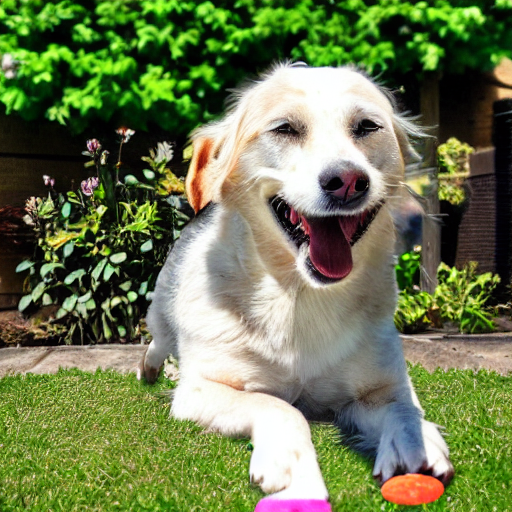

In [22]:
# !pip uninstall -y diffusers # 초기화 후 다시 설치해야 하는 경우 주석 해제
# !pip install diffusers

from diffusers import DiffusionPipeline, UNet2DConditionModel
from transformers import CLIPTextModel
import torch

# 이전 셀에서 OUTPUT_DIR이 정의되었는지 확인
# OUTPUT_DIR은 이미 전역 변수로 정의되어 있습니다.

# Hugging Face의 베이스 모델
model_id = "CompVis/stable-diffusion-v1-4"

# 출력 디렉토리에서 미세조정된 UNet 및 Text Encoder 불러오기
# Dreambooth 훈련이 실패하여 해당 디렉토리에 모델이 없으므로,
# 기본 모델에서 UNet 및 Text Encoder를 로드합니다.
# torch_dtype=torch.float16을 지정하여 파이프라인과 dtype을 통일합니다.
unet = UNet2DConditionModel.from_pretrained(model_id, subfolder="unet", torch_dtype=torch.float16)
text_encoder = CLIPTextModel.from_pretrained(model_id, subfolder="text_encoder", torch_dtype=torch.float16)

# 미세조정된 컴포넌트로 파이프라인 구성하기
# (현재는 기본 모델 컴포넌트로 구성됨)
pipeline_dreambooth = DiffusionPipeline.from_pretrained(
    model_id, unet=unet, text_encoder=text_encoder, torch_dtype=torch.float16
)
pipeline_dreambooth.to("cuda")

# 미세조정된 피사체로 이미지 생성 (현재는 기본 모델로 생성)
# MY_UNIQUE_ID와 MY_UNIQUE_CLASS는 이전 셀에서 정의되었습니다.
prompt_dream = f"A photo of {MY_UNIQUE_ID} {MY_UNIQUE_CLASS} playing in a garden, highly detailed"
image_dream = pipeline_dreambooth(prompt_dream, num_inference_steps=50, guidance_scale=7.5).images[0]

image_dream.save("dreambooth_project_output.png")
print(f"생성된 이미지가 dreambooth_project_output.png로 저장되었습니다. (현재는 미세조정되지 않은 기본 모델로 생성)")
image_dream


In [12]:
!pip uninstall -y diffusers
!pip install -U diffusers transformers peft accelerate torchao

Found existing installation: diffusers 0.41.0.dev0
Uninstalling diffusers-0.41.0.dev0:
  Successfully uninstalled diffusers-0.41.0.dev0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.9/5.9 MB 120.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 832.9/832.9 kB 42.6 MB/s  0:00:00
  Attempting uninstall: peft
    Found existing installation: peft 0.20.0
    Uninstalling peft-0.20.0:
      Successfully uninstalled peft-0.20.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [peft]


## **프로젝트 태스크 3: Checkpoints 및 LoRA를 활용한 개인화된 이미지 생성**

**목표:** Civitai.com과 같은 커뮤니티 플랫폼에서 제공하는 외부 Checkpoint 모델과 LoRA(Low-Rank Adaptation) 파일을 활용하여 독특하고 개인화된 이미지를 생성합니다.

**지시사항:**
1.  **Checkpoint 및 LoRA 선택:** [Civitai.com](https://civitai.com/) 또는 Hugging Face를 탐색하여 원하는 미적 스타일에 맞는 Checkpoint 모델과 호환되는 LoRA 파일을 찾습니다.
    *   **Checkpoint:** Hugging Face의 모델 ID를 기록해 두거나(있는 경우), `.safetensors` 파일을 다운로드할 준비를 합니다.
    *   **LoRA:** `.safetensors` 파일을 Colab 환경으로 다운로드합니다.
2.  **파이프라인 로드:** 선택한 Checkpoint를 사용하여 `StableDiffusionPipeline`을 인스턴스화합니다. `.safetensors` 파일을 다운로드한 경우 로컬로 로드해야 합니다. Hugging Face에 있는 경우 `from_pretrained`를 사용하세요.
3.  **LoRA 가중치 로드:** `pipeline.load_lora_weights()`를 사용하여 다운로드한 LoRA 파일을 적용합니다.
4.  **프롬프트 작성:** 선택한 Checkpoint/LoRA 조합의 기능과 여러분의 비전에 맞춰 이미지 생성을 유도할 수 있도록 상세한 `prompt`와 `negative_prompt`를 작성하세요.
5.  **생성 및 평가:** 이미지를 생성하고 결과를 비판적으로 평가해보세요. Checkpoint와 LoRA가 얼마나 잘 결합되어 원하는 결과를 얻었나요?

*(힌트: LoRA 다운로드 및 파이프라인 구축 예제는 `26-4. Stable diffusion 실습(3)` 섹션을 참고하세요.)*


In [13]:
!pip install -U torchao

In [24]:
from safetensors.torch import load_file, save_file

sd = load_file("my_custom_lora.safetensors")
sd_unet = {k: v for k, v in sd.items() if not k.startswith("lora_te")}
print(len(sd), "->", len(sd_unet))   # 792 -> 576 근처
save_file(sd_unet, "my_custom_lora_unet.safetensors")

pipeline_lora.load_lora_weights(".", weight_name="my_custom_lora_unet.safetensors")

792 -> 576


/usr/local/lib/python3.13/dist-packages/peft/tuners/tuners_utils.py:305: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  # The class of the tuner layer, e.g. `LoraLayer` for LoRA.
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/n

  0%|          | 0/30 [00:00<?, ?it/s]

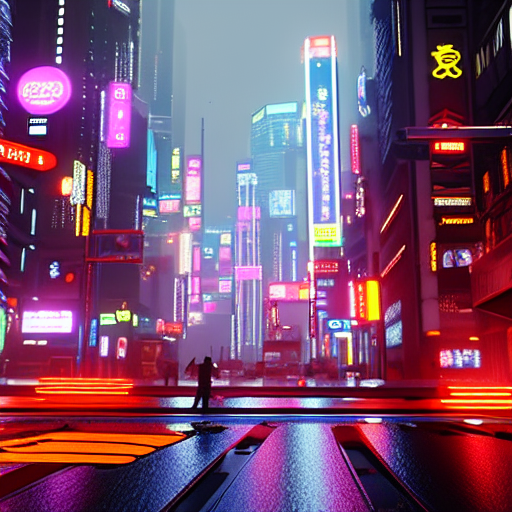

In [27]:
import torch
from diffusers import StableDiffusionPipeline, DPMSolverMultistepScheduler

pipeline_lora = StableDiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    torch_dtype=torch.float16,
    safety_checker=None,
)
pipeline_lora.scheduler = DPMSolverMultistepScheduler.from_config(pipeline_lora.scheduler.config)
pipeline_lora.to("cuda")

# UNet 전용으로 만든 파일 (앞에서 저장한 것)
pipeline_lora.load_lora_weights(".", weight_name="my_custom_lora_unet.safetensors")

pipeline_lora.enable_attention_slicing()  # 메모리 여유가 더 필요할 때

image_final = pipeline_lora(
    prompt="masterpiece, best quality, a cyberpunk city, neon lights, rainy street, cinematic, volumetric lighting, highly detailed",
    negative_prompt="low quality, bad anatomy, deformed, blurry, ugly, text, watermark, signature",
    num_inference_steps=30,
    guidance_scale=7.5,
    generator=torch.Generator(device="cuda").manual_seed(42),
).images[0]

image_final.save("lora_project_output.png")
image_final